<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1>Aprendizaje Automático Avanzado</h1>
    <h3>DBSCAN, HDBSCAN y OPTICS</h3>
</div>


## ¿Qué es el clustering basado en densidad?

El **clustering** agrupa observaciones de modo que las de un mismo grupo sean más parecidas entre sí que las de otros grupos. En aprendizaje no supervisado, la similitud se define mediante una distancia o métrica elegida para las variables.

K-Means busca centroides y suele favorecer grupos convexos, aproximadamente circulares. DBSCAN adopta otra hipótesis:

> Un cluster es una región con muchos puntos cercanos, separada de otras regiones por zonas de baja densidad.

Por eso puede descubrir anillos, medias lunas y formas curvas, además de marcar observaciones aisladas como ruido. No necesita conocer de antemano el número de clusters.

```mermaid
flowchart LR
    A[Datos sin etiquetas] --> B[Definir distancia]
    B --> C[Vecindades de radio eps]
    C --> D{¿Al menos min_samples?}
    D -->|Sí| E[Punto núcleo]
    D -->|No| F[Posible frontera o ruido]
    E --> G[Expandir por conectividad de densidad]
    G --> H[Clusters y etiqueta -1 para ruido]
```

**Idea clave:** DBSCAN no agrupa por cercanía a un centro; agrupa por una cadena de vecindades densas.

## DBSCAN: conceptos y geometría

**DBSCAN** significa *Density-Based Spatial Clustering of Applications with Noise*. Para cada observación $p$, define su vecindad:

$$N_{\varepsilon}(p)=\{q\;|\;d(p,q)\leq\varepsilon\}$$

- **`eps` ($\varepsilon$):** radio máximo para considerar dos puntos vecinos.
- **`min_samples` (MinPts):** cantidad mínima de observaciones en $N_{\varepsilon}(p)$, contando al propio punto.
- **`metric`:** distancia usada; por defecto es euclídea.

### Tipos de puntos

- **Núcleo (core):** $|N_{\varepsilon}(p)|\geq\text{MinPts}$.
- **Frontera (border):** no alcanza MinPts, pero está dentro de la vecindad de un punto núcleo.
- **Ruido (noise):** no es núcleo ni frontera; en `scikit-learn` recibe la etiqueta `-1`.

```text
        radio eps
        .-------.
      .'  o o o  '.       núcleo: suficientes vecinos
     / o  ● ● ●  o \      frontera: cerca de un núcleo
    |    ●   ○     |      ruido: aislado
     \      ×    /
      '-------'
```

Un punto puede ser **directamente alcanzable** desde un núcleo si está dentro de su vecindad. La alcanzabilidad se propaga mediante una cadena de puntos núcleo; esta conectividad por densidad es la que forma un cluster.

## Algoritmo DBSCAN paso a paso

1. Elegir `eps`, `min_samples` y una métrica de distancia.
2. Tomar un punto no visitado y calcular su vecindad $N_{\varepsilon}(p)$.
3. Si tiene menos de MinPts, marcarlo provisionalmente como ruido.
4. Si es núcleo, crear un cluster y añadir sus vecinos.
5. Explorar los vecinos: cada nuevo núcleo aporta su propia vecindad y el cluster se expande.
6. Repetir hasta visitar todos los puntos.

El ruido provisional puede dejar de ser ruido: si más adelante queda dentro de la vecindad de un núcleo, se convierte en punto frontera. La implementación eficiente usa estructuras espaciales como árboles de vecinos cuando la métrica lo permite.

### Complejidad e interpretación

Con un índice espacial adecuado, el costo típico es cercano a $O(n\log n)$; en el peor caso puede llegar a $O(n^2)$. En muchas dimensiones las distancias tienden a parecerse entre sí, fenómeno conocido como **maldición de la dimensionalidad**. En ese caso conviene reducir dimensiones, elegir una métrica apropiada o usar métodos especializados.

> `eps` demasiado pequeño produce demasiado ruido; demasiado grande fusiona clusters. `min_samples` alto exige regiones más densas y suele aumentar el ruido.

### Preparación del entorno

`DBSCAN` y `OPTICS` forman parte de `scikit-learn`. En versiones recientes, `HDBSCAN` también está disponible como `sklearn.cluster.HDBSCAN`; el paquete independiente `hdbscan` es una alternativa compatible con más versiones.

En una terminal, instala las dependencias si todavía no están disponibles:

```bash
python -m pip install -U scikit-learn matplotlib pandas hdbscan
```

> En un entorno administrado, puede ser preferible añadir estas dependencias a `environment.yml` en lugar de ejecutar `pip` desde una celda.

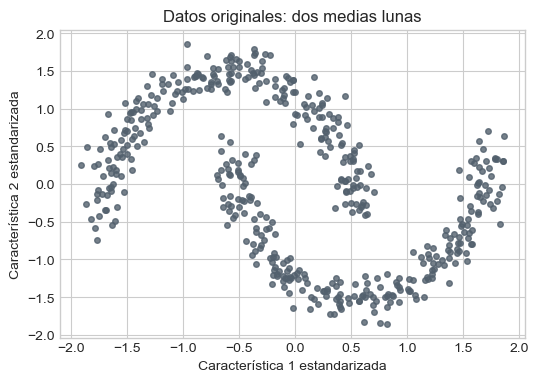

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')

# Dos medias lunas: una forma no convexa que desafía a K-Means.
X, y_referencia = make_moons(n_samples=500, noise=0.08, random_state=42)
X = StandardScaler().fit_transform(X)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X[:, 0], X[:, 1], s=16, color='#52606d', alpha=0.8)
ax.set(title='Datos originales: dos medias lunas', xlabel='Característica 1 estandarizada', ylabel='Característica 2 estandarizada')
plt.show()

### DBSCAN en acción

La estandarización es importante porque `eps` se expresa en las unidades de la distancia. Si una variable está en miles y otra entre 0 y 1, la primera dominará la vecindad.

Probamos un `eps` inicial y observamos dos salidas: las etiquetas de cluster y el porcentaje de ruido. La etiqueta `-1` **no es un cluster adicional**.

Clusters encontrados: 2
Puntos de ruido: 0 (0.0%)


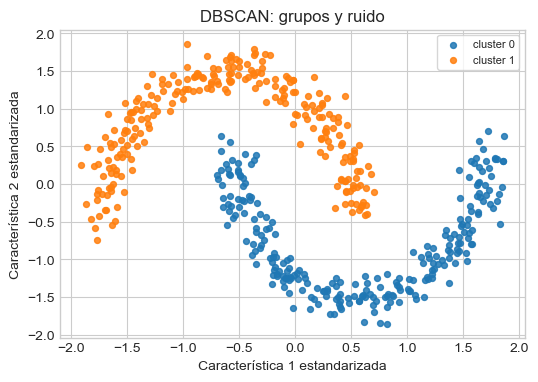

In [2]:
dbscan = DBSCAN(eps=0.30, min_samples=5, metric='euclidean')
labels_dbscan = dbscan.fit_predict(X)

n_clusters = len(set(labels_dbscan)) - int(-1 in labels_dbscan)
n_noise = int(np.sum(labels_dbscan == -1))
print(f'Clusters encontrados: {n_clusters}')
print(f'Puntos de ruido: {n_noise} ({n_noise / len(X):.1%})')

fig, ax = plt.subplots(figsize=(6, 4))
unique_labels = sorted(set(labels_dbscan))
for label in unique_labels:
    mask = labels_dbscan == label
    name = 'ruido (-1)' if label == -1 else f'cluster {label}'
    color = '#263238' if label == -1 else plt.cm.tab10(label % 10)
    ax.scatter(X[mask, 0], X[mask, 1], s=18, c=[color], alpha=0.85, label=name)
ax.set(title='DBSCAN: grupos y ruido', xlabel='Característica 1 estandarizada', ylabel='Característica 2 estandarizada')
ax.legend(frameon=True, fontsize=8)
plt.show()

### Experimento: círculos concéntricos

Este ejemplo reproduce una idea del material fuente: grupos con forma de anillo y puntos aleatorios. K-Means los separa mal porque asigna por distancia al centroide; DBSCAN puede seguir la geometría local.

La visualización es una evidencia cualitativa. En un problema real también revisaríamos estabilidad, ruido y métricas externas si contamos con etiquetas de referencia.

c:\Users\uie70742\.conda\envs\aaa_curso_2026\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


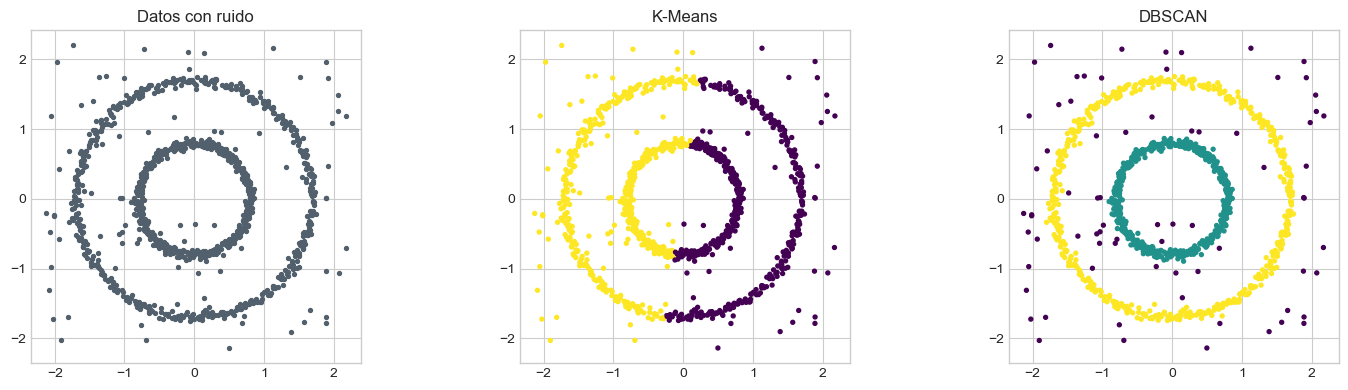

In [4]:
rng = np.random.default_rng(42)
angles = np.linspace(0, 2 * np.pi, 500, endpoint=False)
ring_inner = np.c_[np.cos(angles), np.sin(angles)] * 0.8 + rng.normal(0, 0.035, (500, 2))
ring_outer = np.c_[np.cos(angles), np.sin(angles)] * 1.7 + rng.normal(0, 0.035, (500, 2))
noise = rng.uniform(-2.2, 2.2, size=(100, 2))
X_rings = np.vstack([ring_inner, ring_outer, noise])

from sklearn.cluster import KMeans
kmeans_labels = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(X_rings)
rings_labels = DBSCAN(eps=0.12, min_samples=8).fit_predict(X_rings)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plots = [(np.full(len(X_rings), 0), 'Datos con ruido'), (kmeans_labels, 'K-Means'), (rings_labels, 'DBSCAN')]
for ax, (labels, title) in zip(axes, plots):
    if title == 'Datos con ruido':
        ax.scatter(X_rings[:, 0], X_rings[:, 1], s=8, c='#52606d')
    else:
        ax.scatter(X_rings[:, 0], X_rings[:, 1], s=8, c=labels, cmap='viridis')
    ax.set(title=title, aspect='equal')
plt.tight_layout()
plt.show()

## Elegir `eps` y `min_samples`

No existe un valor universal: ambos dependen de la escala, la métrica y el dominio.

### Gráfico de k-distancias

Una heurística útil es fijar $k=\text{min\_samples}$, calcular para cada punto la distancia a su vecino número $k$, ordenar esas distancias y buscar el **codo**. El salto final suele separar puntos de baja densidad de la estructura de los clusters.

```mermaid
flowchart LR
    A[Elegir min_samples] --> B[Calcular distancia al k-ésimo vecino]
    B --> C[Ordenar distancias]
    C --> D[Buscar el codo]
    D --> E[Probar eps alrededor del codo]
    E --> F[Validar clusters y ruido]
```

La heurística debe combinarse con conocimiento del problema. Repite el análisis con varios valores cercanos y comprueba la estabilidad de los grupos; no elijas `eps` solo porque produzca un número de clusters esperado.

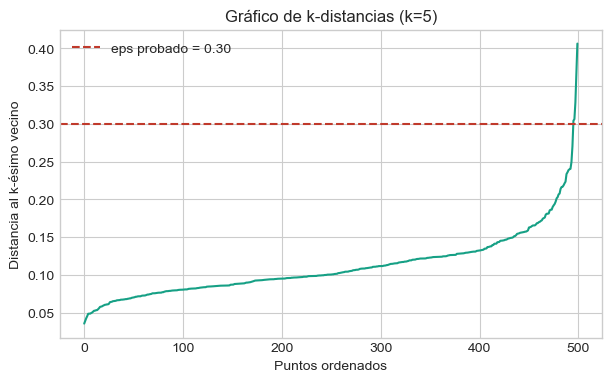

In [3]:
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X)
distances, _ = neighbors.kneighbors(X)
k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_distances, color='#16a085')
ax.set(title=f'Gráfico de k-distancias (k={min_samples})', xlabel='Puntos ordenados', ylabel='Distancia al k-ésimo vecino')
ax.axhline(0.30, color='#c0392b', linestyle='--', label='eps probado = 0.30')
ax.legend()
plt.show()

## HDBSCAN: densidades variables

**HDBSCAN** (*Hierarchical Density-Based Spatial Clustering of Applications with Noise*) extiende DBSCAN construyendo una jerarquía de agrupamientos a diferentes niveles de densidad. En lugar de fijar un único `eps`, estudia cómo aparecen, se dividen y desaparecen los grupos cuando cambia la escala.

### ¿Por qué mejora a DBSCAN?

DBSCAN utiliza un radio global $\varepsilon$. Si un grupo es muy denso y otro es disperso, un radio pequeño fragmenta el grupo disperso y uno grande fusiona grupos cercanos. HDBSCAN compara muchos niveles de densidad y selecciona los agrupamientos que permanecen estables durante más tiempo.

### De la distancia a una jerarquía

Para cada punto $x$, HDBSCAN define una **distancia al núcleo** (*core distance*) usando la distancia a su $k$-ésimo vecino, donde $k$ se relaciona con `min_samples`:

$$\operatorname{core}_k(x)=d(x,\text{k-ésimo vecino de }x)$$

Después reemplaza la distancia ordinaria entre dos puntos por la **distancia de alcanzabilidad mutua**:

$$d_{\mathrm{mreach},k}(a,b)=\max\{\operatorname{core}_k(a),\operatorname{core}_k(b),d(a,b)\}$$

Esta definición evita que un punto aislado parezca artificialmente cercano a un cluster denso. Con estas distancias se construye un grafo y un árbol de expansión mínima (*minimum spanning tree*, MST). El árbol representa cómo se conectan los puntos al pasar de regiones muy densas a regiones menos densas.

```mermaid
flowchart LR
    A[Distancias entre puntos] --> B[Distancia al núcleo]
    B --> C[Distancia de alcanzabilidad mutua]
    C --> D[Árbol de expansión mínima]
    D --> E[Jerarquía de densidad]
    E --> F[Árbol condensado]
    F --> G[Clusters más estables]
```

### Árbol condensado y estabilidad

La jerarquía se analiza mediante $\lambda=1/d$: valores grandes de $\lambda$ representan mayor densidad. El árbol condensado conserva las ramas que alcanzan `min_cluster_size` y registra cuándo nacen, se dividen o desaparecen.

Si un cluster $C$ persiste entre $\lambda_{\mathrm{birth}}$ y $\lambda_{\mathrm{death}}$, su estabilidad puede entenderse intuitivamente como el área bajo su persistencia:

$$\operatorname{Stability}(C)\approx\sum_{x\in C}\left(\lambda_{\mathrm{death}}(x)-\lambda_{\mathrm{birth}}(C)\right)$$

Los grupos que persisten en un intervalo amplio de densidades suelen ser más confiables. HDBSCAN selecciona una partición basada en esa estabilidad, no simplemente en el número de clusters solicitado.

### Probabilidad de pertenencia

Además de `labels_`, HDBSCAN puede producir `probabilities_`. Para un punto asignado al cluster $C$, esta probabilidad se interpreta como una medida de qué tan fuerte es su pertenencia:

$$p(x\in C)\in[0,1]$$

- $p\approx1$: punto central y estable.
- $p$ intermedia: punto cercano a una frontera.
- $p\approx0$: punto débilmente asociado o ruido.

No es una probabilidad supervisada calibrada como la de un clasificador; es una medida de estabilidad relativa dentro de la jerarquía.

### Parámetros importantes

- **`min_cluster_size`:** tamaño mínimo de un grupo que se conservará. Aumentarlo produce menos clusters, más grandes y más conservadores.
- **`min_samples`:** controla cuánto debe concentrarse una región para considerarse densa. Aumentarlo suele producir más puntos de ruido y clusters más robustos.
- **`cluster_selection_method`:** `"eom"` selecciona grupos estables de forma automática; `"leaf"` favorece las hojas más pequeñas y puede descubrir subclusters.
- **`metric`:** define la geometría del espacio. Debe ser coherente con la escala y la naturaleza de las variables.

> HDBSCAN reduce la sensibilidad a un único radio, pero no elimina la necesidad de elegir una métrica, revisar la escala de las variables e interpretar el ruido.

HDBSCAN -> clusters: 2 | ruido: 8


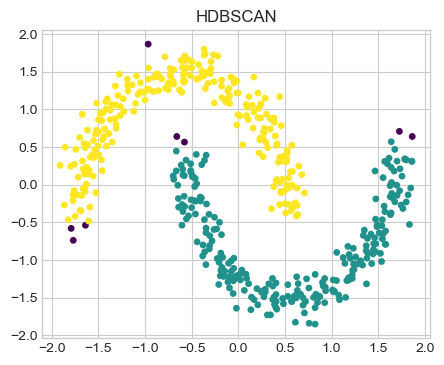

In [6]:
# HDBSCAN: en sklearn >= 1.3 -> from sklearn.cluster import HDBSCAN
try:
    from sklearn.cluster import HDBSCAN
    hdb = HDBSCAN(min_cluster_size=15)
    labels_h = hdb.fit_predict(X)
except ImportError:
    import hdbscan
    hdb = hdbscan.HDBSCAN(min_cluster_size=15)
    labels_h = hdb.fit_predict(X)

n_clusters_h = len(set(labels_h)) - (1 if -1 in labels_h else 0)
print(f'HDBSCAN -> clusters: {n_clusters_h} | ruido: {np.sum(labels_h == -1)}')

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=labels_h, cmap='viridis', s=15)
plt.title('HDBSCAN')
plt.show()

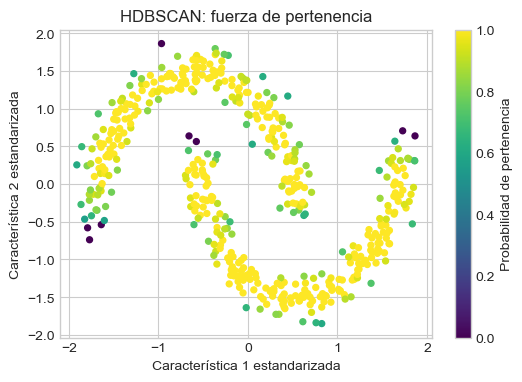

Pertenencia media (puntos no ruido): 0.950


In [8]:
# La confianza de pertenencia ayuda a localizar fronteras y puntos ambiguos.
probabilities_h = getattr(hdb, 'probabilities_', np.where(labels_h == -1, 0.0, 1.0))

fig, ax = plt.subplots(figsize=(6, 4))
scatter = ax.scatter(X[:, 0], X[:, 1], c=probabilities_h, cmap='viridis', vmin=0, vmax=1, s=18)
ax.set(title='HDBSCAN: fuerza de pertenencia', xlabel='Característica 1 estandarizada', ylabel='Característica 2 estandarizada')
fig.colorbar(scatter, ax=ax, label='Probabilidad de pertenencia')
plt.show()

print(f'Pertenencia media (puntos no ruido): {probabilities_h[labels_h != -1].mean():.3f}')

## OPTICS: explorar la estructura a varias escalas

**OPTICS** (*Ordering Points To Identify the Clustering Structure*) generaliza la idea de DBSCAN. En vez de comprometerse con un único radio `eps`, construye un ordenamiento de los puntos y registra la densidad necesaria para que cada punto sea alcanzable desde otro. Después podemos extraer clusters con distintos niveles de densidad.

### Magnitudes principales

Sea $k=\text{min\_samples}$. La distancia al núcleo de un punto $p$ es:

$$\operatorname{core\_dist}_k(p)=d(p,\text{k-ésimo vecino de }p)$$

Si $o$ es un punto que precede a $p$ en el recorrido, la distancia de alcanzabilidad de $p$ respecto a $o$ es:

$$\operatorname{reachability}(p\mid o)=\max\{\operatorname{core\_dist}_k(o),d(o,p)\}$$

Una distancia pequeña indica que $p$ puede alcanzarse desde una región densa; una distancia grande indica una separación o una zona de baja densidad. `reachability_` contiene estas distancias y `ordering_` indica el orden de los índices en el que deben dibujarse.

### Algoritmo conceptual

1. Elegir `min_samples` y un `max_eps` suficientemente amplio.
2. Visitar un punto y calcular su distancia al núcleo.
3. Insertar sus vecinos candidatos en una cola priorizada por distancia de alcanzabilidad.
4. Procesar primero el vecino más accesible y actualizar sus candidatos.
5. Continuar hasta ordenar todas las observaciones.
6. Extraer clusters a partir de los valles del diagrama, usando `xi` o un `eps` de corte.

```mermaid
flowchart TD
    A[Datos escalados] --> B[Calcular vecinos y core distance]
    B --> C[Construir ordering]
    C --> D[Calcular reachability]
    D --> E[Graficar distancias]
    E --> F{Método de extracción}
    F -->|xi| G[Detectar cambios relativos de pendiente]
    F -->|eps| H[Aplicar un corte horizontal]
    G --> I[Etiquetas y ruido]
    H --> I
```

### Cómo leer el diagrama de alcanzabilidad

- Un **valle profundo** suele corresponder a un cluster denso.
- La anchura del valle refleja aproximadamente cuántos puntos contiene.
- Un valle separado por un pico alto sugiere dos grupos diferentes.
- Los puntos con alcanzabilidad infinita o muy alta suelen iniciar componentes o comportarse como ruido.

`xi` detecta cambios relativos en la pendiente y puede descubrir grupos con densidades distintas. Alternativamente, `cluster_method='dbscan'` permite extraer una partición con un umbral `eps` concreto, útil para comparar OPTICS directamente con DBSCAN.

> OPTICS no “adivina” una única segmentación verdadera: conserva más información de la geometría y deja que la extracción responda a la escala que interesa.

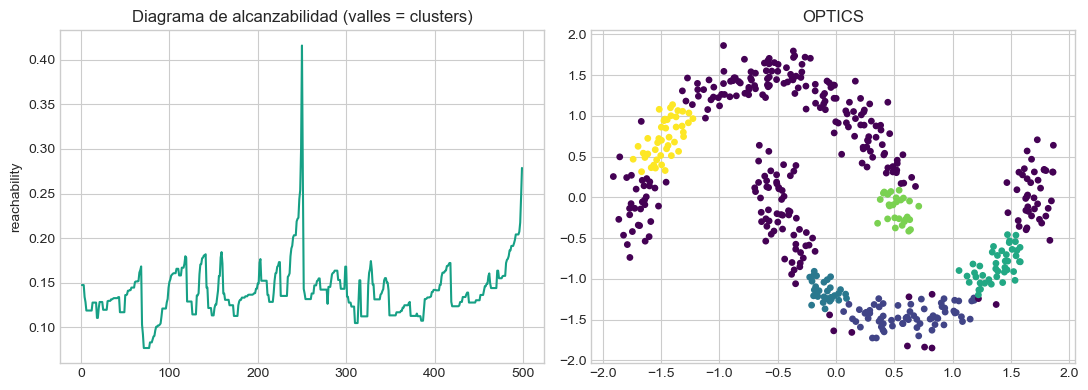

In [9]:
from sklearn.cluster import OPTICS

opt = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05).fit(X)
labels_o = opt.labels_

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
# Diagrama de alcanzabilidad
space = np.arange(len(X))
reachability = opt.reachability_[opt.ordering_]
ax[0].plot(space, reachability, color='#16a085')
ax[0].set_title('Diagrama de alcanzabilidad (valles = clusters)')
ax[0].set_ylabel('reachability')
# Clusters
ax[1].scatter(X[:, 0], X[:, 1], c=labels_o, cmap='viridis', s=15)
ax[1].set_title('OPTICS')
plt.tight_layout()
plt.show()

### Sensibilidad de la extracción

El ordenamiento se calcula una sola vez, pero la extracción puede cambiar. `xi` controla qué tan pronunciado debe ser el cambio de densidad para separar un valle: valores pequeños detectan más divisiones; valores grandes producen una estructura más conservadora.

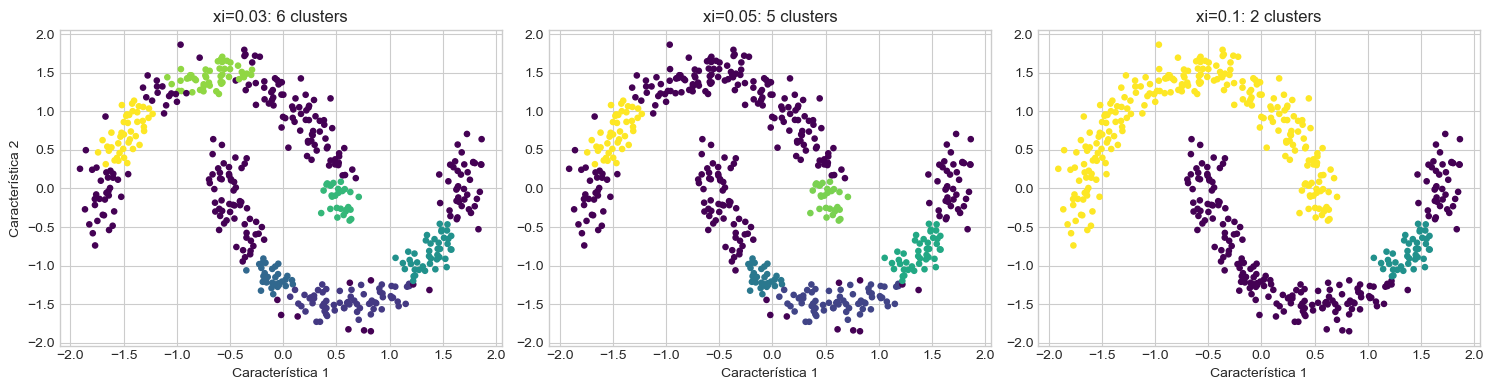

In [10]:
from sklearn.cluster import OPTICS
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

X_optics, _ = make_moons(n_samples=500, noise=0.08, random_state=42)
X_optics = StandardScaler().fit_transform(X_optics)

xi_values = [0.03, 0.05, 0.10]
fig, axes = plt.subplots(1, len(xi_values), figsize=(15, 4))
for ax, xi in zip(axes, xi_values):
    model = OPTICS(min_samples=10, xi=xi, min_cluster_size=0.05).fit(X_optics)
    labels = model.labels_
    n_clusters = len(set(labels)) - int(-1 in labels)
    ax.scatter(X_optics[:, 0], X_optics[:, 1], c=labels, cmap='viridis', s=14)
    ax.set(title=f'xi={xi}: {n_clusters} clusters', xlabel='Característica 1')
axes[0].set_ylabel('Característica 2')
plt.tight_layout()
plt.show()

## Ejemplo sencillo con dataset Iris

El conjunto Iris tiene cuatro variables con escalas comparables, pero aun así lo estandarizamos. La columna `target` se conserva únicamente para comparar al final; **no participa en el ajuste**, porque DBSCAN es no supervisado.

Para evaluar sin etiquetas podemos usar el coeficiente de silueta solo sobre puntos no considerados ruido. Esta métrica favorece grupos compactos y separados, pero no siempre premia correctamente formas curvas; debe interpretarse junto con la gráfica y el conocimiento del dominio.

Clusters en Iris: 2
Ruido: 4 observaciones
Silueta sin ruido: 0.598


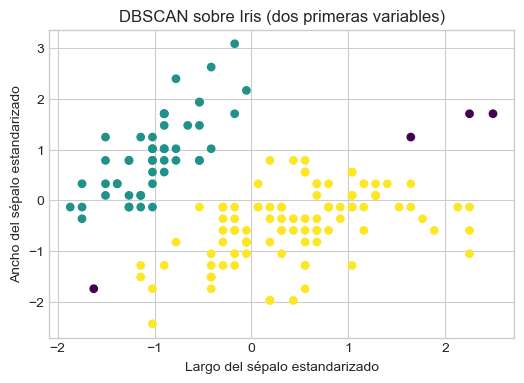

In [5]:
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score

iris = load_iris(as_frame=True)
features_iris = StandardScaler().fit_transform(iris.data)
labels_iris = DBSCAN(eps=0.8, min_samples=6).fit_predict(features_iris)

valid = labels_iris != -1
n_clusters_iris = len(set(labels_iris)) - int(-1 in labels_iris)
print(f'Clusters en Iris: {n_clusters_iris}')
print(f'Ruido: {np.sum(~valid)} observaciones')
if n_clusters_iris >= 2 and valid.sum() > n_clusters_iris:
    print(f'Silueta sin ruido: {silhouette_score(features_iris[valid], labels_iris[valid]):.3f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(features_iris[:, 0], features_iris[:, 1], c=labels_iris, cmap='viridis', s=28)
ax.set(title='DBSCAN sobre Iris (dos primeras variables)', xlabel='Largo del sépalo estandarizado', ylabel='Ancho del sépalo estandarizado')
plt.show()

|  | **DBSCAN** | **HDBSCAN** | **OPTICS** |
|---|---|---|---|
| Parámetros principales | `eps`, `min_samples` | `min_cluster_size` | `min_samples`, `xi` |
| ¿Usa un `eps` único? | Sí | No | No; explora un rango |
| Densidades variables | Limitado | Bueno | Bueno |
| Detecta ruido | Sí | Sí, con probabilidades | Sí |
| Salida distintiva | Etiquetas | Jerarquía y estabilidad | Ordenamiento de alcanzabilidad |

- **DBSCAN:** primera opción cuando la densidad es relativamente uniforme y se necesita un método sencillo.
- **HDBSCAN:** preferible cuando hay densidades diferentes o se necesitan puntuaciones de pertenencia.
- **OPTICS:** útil para inspeccionar la estructura a múltiples escalas mediante su diagrama de alcanzabilidad.

Ninguno garantiza que exista una “verdad” única: cambiar la métrica o la escala cambia la geometría del problema.

- [Documentación de `sklearn.cluster.DBSCAN`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html)
- [Documentación de `sklearn.cluster.OPTICS`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.OPTICS.html)
- [Documentación de `sklearn.cluster.HDBSCAN`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html)
- [Artículo original de DBSCAN, Ester et al. (1996)](https://www.aaai.org/Papers/KDD/1996/KDD96-037.pdf)
- [Tutorial fuente en inglés con ejemplos de Scikit-learn](https://www.machinecurve.com/index.php/2020/12/09/performing-dbscan-clustering-with-python-and-scikit-learn/)
